In [ ]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

# Testing Two-Stage Rejection: Median Pre-Filter + Post-Fit Rejection

**Strategy:** Combine a cheap pre-fit gate with post-fit quality control:

1. **Stage 1 — Median pre-filter:** Compute `A_median = sum(smoothed - median(smoothed))`.
   If `A_median < 2 pe`, flag for deletion (skip fitting entirely).
   - Noise is symmetric after smoothing → `A_median ≈ 0`
   - Real spots break symmetry → `A_median > 0`
   - This saves computation by not fitting obvious noise patches.

2. **Stage 2 — Fit + post-fit rejection:** For puncta passing the gate, fit with the
   original min-subtraction IG (which the fitter handles well), then reject if:
   - `fitted_photons < threshold` (noise fits converge to ~7 pe)
   - `chi_squared > 3` (poor fit quality)

**Test range:** 0 (noise), 100–500 photoelectrons for ATTO 565, bg=5 pe.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import time
from copy import copy
from numba import jit


from pyS3M import gaussoptfuncs
from pyS3M import IOFunctions
from pyS3M import Multicolour_Simulation_Functions
from pyS3M import PSFFunctions
from pyS3M import SpectralFunctions
from pyS3M import sCMOSFunctions
from pyS3M import MaskFunctions
from pyS3M import ImageAnalysisFunctions
from pyS3M.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)
import types

IO = IOFunctions.IO_Functions()
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()
PSF = PSFFunctions.PSF_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
sCMOS = sCMOSFunctions.sCMOS_Functions()
M_F = MaskFunctions.Mask_Functions()
I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

print("Imports done.")

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260217_182242.log


Imports done.


## 1. Camera & Spectral Setup (same as Figure 1 notebook)

In [2]:
image_size = 14
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
masks_3d = np.dstack([masks[c] for c in ["B", "G", "R"]])

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

# Camera calibration (uniform, using Ximea medians)
data_folder = "../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

camera_parameters = {
    "gain": np.full((image_size, image_size), np.median(gain)),
    "offset": np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise": np.full((image_size, image_size), np.median(readnoise)),
    "rqe": np.full((image_size, image_size), np.median(rqe)),
    "masks": masks,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
}
camera_params = CameraParameters.validate_and_create(camera_parameters)

# Smoothing function
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

# Filters
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
filters = [dichroic_mirror, notch_filter]

# ATTO 565 spectral properties
dye = "ATTO 565"
average_emission_wavelength, dye_pixel_efficiency = (
    MSF.spectral.get_pixel_fractions_dye_and_filters(
        [dye], filters, wavelength, pixel_QYs, normalized=False
    )
)
dye_colour_ratios = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

sigma_PSF = PSF.sigma_PSF(average_emission_wavelength, 1.49)
pixel_size = 69  # nm

print(f"Dye: {dye}")
print(f"Average emission wavelength: {average_emission_wavelength:.1f} nm")
print(f"Colour ratios (B, G, R): {dye_colour_ratios.ravel()}")
print(f"Sigma PSF: {sigma_PSF:.1f} nm = {sigma_PSF/pixel_size:.2f} px")
print(f"Gain (median): {np.median(gain):.2f} ADU/pe")
print(f"Readnoise (median): {np.median(readnoise):.2f} pe")

Dye: ATTO 565
Average emission wavelength: 611.6 nm
Colour ratios (B, G, R): [ 0.026076    0.39223775  0.58168625]
Sigma PSF: 92.4 nm = 1.34 px
Gain (median): 0.41 ADU/pe
Readnoise (median): 2.34 pe


## 2. Define the Median Amplitude Estimator (Pre-Filter)

Compute `A_median = sum(smoothed - median(smoothed))` for each punctum.
- For symmetric noise: `A_median ≈ 0` (median splits the distribution evenly)
- For a real spot: the peaked centre skews the distribution right, so `A_median > 0`

In [3]:
@jit(nopython=True)
def compute_A_median(smoothed_data):
    """
    Compute median-subtracted amplitude estimate.
    
    A_median = sum(smoothed - median(smoothed))
    
    For symmetric noise this is ~0; for a real spot it's > 0
    because the bright peak skews the distribution.
    """
    flat = smoothed_data.ravel().copy()
    # Sort for median
    flat.sort()
    n = len(flat)
    if n % 2 == 0:
        median_val = (flat[n // 2 - 1] + flat[n // 2]) / 2.0
    else:
        median_val = flat[n // 2]
    
    A = 0.0
    for i in range(n):
        A += flat[i] - median_val
    return A

# Warm up JIT
_ = compute_A_median(np.random.randn(14, 14).astype(np.float32))
print("Median amplitude estimator compiled.")

Median amplitude estimator compiled.


## 3. Simulate & Run Two-Stage Filter

For each photon level and each punctum:
1. Compute `A_median` from smoothed data
2. If `A_median < median_gate` → reject pre-fit (Stage 1)
3. Otherwise, fit with original IG (min subtraction)
4. Record fit results for post-fit rejection analysis (Stage 2)

In [4]:
from scipy.optimize import leastsq

# Test parameters
n_bootstrap = 1000
background_photons = 5.0
background_colour = [1, 1, 1]
NA = 1.49

# Photon levels: 0 (noise only) + fine grid from 100 to 500
photon_levels = np.concatenate([[0], np.arange(100, 550, 50)])
print(f"Testing photon levels: {photon_levels}")

# Stage 1 gate threshold
median_gate = 2.0  # pe — reject if A_median < this
print(f"Median gate threshold: {median_gate} pe")

# Config for simulation
config = SimulationConfig(
    n_bootstrap=n_bootstrap,
    background_photons=background_photons,
    background_colour=background_colour,
    NA=NA,
    pixel_size=pixel_size,
    cpu_fraction=0.9,
    save_raw_results=False,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
)

# Pre-compute spectrum for stochastic photon sampling
dye_spectrum = S_F.get_dye_or_filter_data(
    names=[dye], wavelength=wavelength, dye_or_filter=True
)
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)
total_filter_transmission = np.prod(filter_spectra, axis=0)
full_spectrum = dye_spectrum[0] * total_filter_transmission


def fit_single(punctum, smoothed, masks, weights):
    """Fit a single punctum with original (min-subtraction) IG.
    Returns [total_pe, A_B, A_G, A_R, chi_sqr, ig_total] or NaNs on failure.
    """
    size = int(punctum.shape[0])
    ravelsize = size * size

    ig = np.array(
        gaussoptfuncs.initial_guess(smoothed, punctum, masks), dtype=np.float64
    )
    ig_total = ig[7] ** 2 + ig[8] ** 2 + ig[9] ** 2

    try:
        pfit, pcov, infodict, errmsg, success = leastsq(
            gaussoptfuncs.WLS_chi_nobounds,
            x0=ig,
            args=(punctum, masks, weights, size, ravelsize),
            full_output=True,
            ftol=1e-8,
            xtol=1e-8,
        )

        if success not in [1, 2, 3, 4]:
            return np.full(6, np.nan)

        A_B = pfit[7] ** 2
        A_G = pfit[8] ** 2
        A_R = pfit[9] ** 2
        total = A_B + A_G + A_R

        residuals = gaussoptfuncs.WLS_chi_nobounds(
            pfit, punctum, masks, weights, size, ravelsize
        )
        chi_sqr = np.sum(residuals**2) / (ravelsize - len(ig))

        return np.array([total, A_B, A_G, A_R, chi_sqr, ig_total])
    except Exception:
        return np.full(6, np.nan)


print("Fit function defined.")

Testing photon levels: [  0 100 150 200 250 300 350 400 450 500]
Median gate threshold: 2.0 pe
Fit function defined.


In [5]:
# Run the simulation + two-stage filter for each photon level
# fit_results columns: [total_pe, A_B, A_G, A_R, chi_sqr, ig_total]
fit_results = {}      # fit results (NaN where not fitted due to gate)
a_median_values = {}  # A_median for each punctum (always computed)

# Setup positions
image_size_nm = pixel_size * image_size
rng = np.random.default_rng(42)
x0 = np.full(n_bootstrap, image_size_nm / 2) + rng.uniform(
    -pixel_size, pixel_size, n_bootstrap
)
y0 = np.full(n_bootstrap, image_size_nm / 2) + rng.uniform(
    -pixel_size, pixel_size, n_bootstrap
)
x0y0 = {"dye": np.zeros([n_bootstrap, 2, 1])}
x0y0["dye"][:, 0, 0] = x0
x0y0["dye"][:, 1, 0] = y0

t_start = time.time()

for pi, n_photon in enumerate(photon_levels):
    n_photons = {"dye": np.full(n_bootstrap, n_photon)}

    if n_photon > 0:
        mean_wl_boot, colour_ratios_boot = S_F.generate_bootstrap_colour_ratios(
            full_spectrum,
            wavelength,
            pixel_QYs,
            n_photons_per_image=int(n_photon),
            n_bootstrap=n_bootstrap,
            pixel_order=["B", "G", "R"],
            pixel_order_indices={"B": 0, "G": 1, "R": 2},
            random_state=np.random.default_rng(),
        )
        avg_wl = mean_wl_boot
        dye_pe = colour_ratios_boot
    else:
        avg_wl = average_emission_wavelength
        dye_pe = dye_pixel_efficiency

    bayer_image, smoothed_image, _ = MSF.gen_camera_image_stack(
        camera_parameters,
        wavelength,
        avg_wl,
        dye_pe,
        n_photons,
        x0y0,
        smoothing_function=smoothing_function,
        background_photons=background_photons,
        background_colour=background_colour,
        NA=NA,
        pixel_size=pixel_size,
        return_normal_image=False,
    )

    pe_data = (
        (bayer_image - camera_params.offset) / camera_params.gain / camera_params.rqe
    )
    sm_data = (
        (smoothed_image - camera_params.offset)
        / camera_params.gain
        / camera_params.rqe
    )

    # Weights: 1/variance, matching production code (Multicolour_Simulation_Functions line 626-630)
    # variance = smoothed_pe + 1 + readnoise² (Poisson shot noise + read noise)
    error_data = sm_data.copy()
    error_data[error_data < 0] = 0
    error_data = error_data + 1
    weights_map = 1.0 / (error_data + np.median(readnoise) ** 2)

    res = np.full((n_bootstrap, 6), np.nan)
    a_med = np.zeros(n_bootstrap)

    n_gated = 0
    for j in range(n_bootstrap):
        s = sm_data[j].astype(np.float32)
        a_med[j] = compute_A_median(s)

        # Stage 1: median gate
        if a_med[j] < median_gate:
            n_gated += 1
            continue  # skip fitting, res[j] stays NaN

        # Stage 2: fit with original IG
        p = pe_data[j].astype(np.float32)
        w = weights_map[j].astype(np.float32)
        res[j] = fit_single(p, s, masks_3d, w)

    fit_results[n_photon] = res
    a_median_values[n_photon] = a_med

    # Stats for fitted puncta only
    fitted_mask = ~np.isnan(res[:, 0])
    elapsed = (time.time() - t_start) / 60.0
    print(
        f"Photon={n_photon:5d} | "
        f"Gated={n_gated:4d} ({n_gated/n_bootstrap*100:5.1f}%) | "
        f"Fitted={np.sum(fitted_mask):4d} | "
        f"Fit med={np.nanmedian(res[:, 0]):7.1f} pe, "
        f"chi2={np.nanmedian(res[fitted_mask, 4]):5.3f} | "
        f"A_median: med={np.median(a_med):6.1f}, "
        f"min={np.min(a_med):6.1f} | {elapsed:.1f} min"
    )

print(f"\nDone in {(time.time()-t_start)/60:.1f} min")

Photon=    0 | Gated= 585 ( 58.5%) | Fitted= 409 | Fit med=    5.1 pe, chi2=1.182 | A_median: med=  -0.4, min= -38.9 | 0.1 min
Photon=  100 | Gated= 563 ( 56.3%) | Fitted= 431 | Fit med=  172.0 pe, chi2=1.058 | A_median: med=  -0.3, min= -50.7 | 0.1 min
Photon=  150 | Gated= 391 ( 39.1%) | Fitted= 607 | Fit med=  196.9 pe, chi2=1.069 | A_median: med=   6.2, min= -46.5 | 0.1 min
Photon=  200 | Gated= 286 ( 28.6%) | Fitted= 709 | Fit med=  218.3 pe, chi2=1.053 | A_median: med=  11.4, min= -49.0 | 0.1 min
Photon=  250 | Gated= 157 ( 15.7%) | Fitted= 843 | Fit med=  255.2 pe, chi2=1.062 | A_median: med=  18.4, min= -32.1 | 0.1 min
Photon=  300 | Gated=  71 (  7.1%) | Fitted= 928 | Fit med=  289.4 pe, chi2=1.060 | A_median: med=  27.5, min= -24.3 | 0.2 min
Photon=  350 | Gated=  34 (  3.4%) | Fitted= 966 | Fit med=  330.5 pe, chi2=1.068 | A_median: med=  37.8, min= -15.9 | 0.2 min
Photon=  400 | Gated=   9 (  0.9%) | Fitted= 991 | Fit med=  373.7 pe, chi2=1.062 | A_median: med=  47.4, min= 

## 4. Stage 1 Analysis: Median Pre-Filter

How well does `A_median < 2 pe` separate noise from signal?

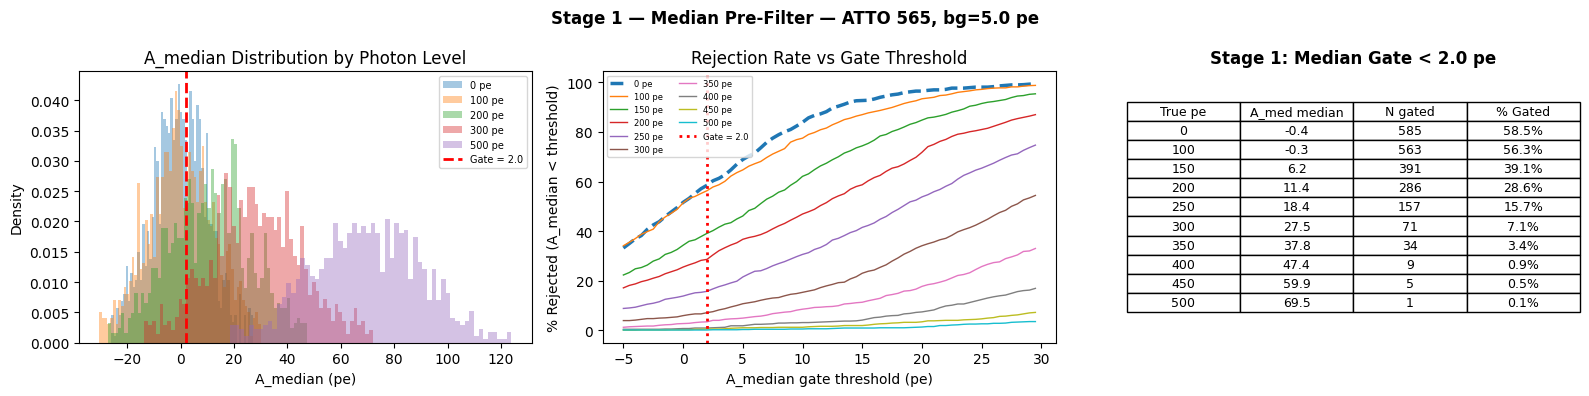

In [6]:
# Stage 1: Median gate performance
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: A_median distributions for noise vs signal
ax = axes[0]
for p in [0, 100, 200, 300, 500]:
    vals = a_median_values[p]
    clip_hi = np.percentile(vals, 99)
    clip_lo = np.percentile(vals, 1)
    show = vals[(vals >= clip_lo) & (vals <= clip_hi)]
    ax.hist(show, bins=60, alpha=0.4, density=True, label=f"{p} pe")
ax.axvline(median_gate, color="red", linestyle="--", linewidth=2, label=f"Gate = {median_gate}")
ax.set_xlabel("A_median (pe)")
ax.set_ylabel("Density")
ax.set_title("A_median Distribution by Photon Level")
ax.legend(fontsize=7)

# Panel 2: Gate rejection rate vs threshold sweep
ax = axes[1]
gate_thresholds = np.arange(-5, 30, 0.5)
for p in photon_levels:
    rates = [
        np.sum(a_median_values[p] < t) / n_bootstrap * 100 for t in gate_thresholds
    ]
    ls = "--" if p == 0 else "-"
    lw = 2.5 if p == 0 else 1
    ax.plot(gate_thresholds, rates, ls, linewidth=lw, label=f"{p} pe")
ax.axvline(median_gate, color="red", linestyle=":", linewidth=2, label=f"Gate = {median_gate}")
ax.set_xlabel("A_median gate threshold (pe)")
ax.set_ylabel("% Rejected (A_median < threshold)")
ax.set_title("Rejection Rate vs Gate Threshold")
ax.legend(fontsize=6, ncol=2)

# Panel 3: Summary table
ax = axes[2]
ax.axis("off")
table_data = []
for p in photon_levels:
    n_gated = np.sum(a_median_values[p] < median_gate)
    pct = n_gated / n_bootstrap * 100
    med_val = np.median(a_median_values[p])
    table_data.append([f"{p}", f"{med_val:.1f}", f"{n_gated}", f"{pct:.1f}%"])
table = ax.table(
    cellText=table_data,
    colLabels=["True pe", "A_med median", "N gated", "% Gated"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)
ax.set_title(f"Stage 1: Median Gate < {median_gate} pe", fontweight="bold")

plt.suptitle(
    f"Stage 1 — Median Pre-Filter — {dye}, bg={background_photons} pe",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

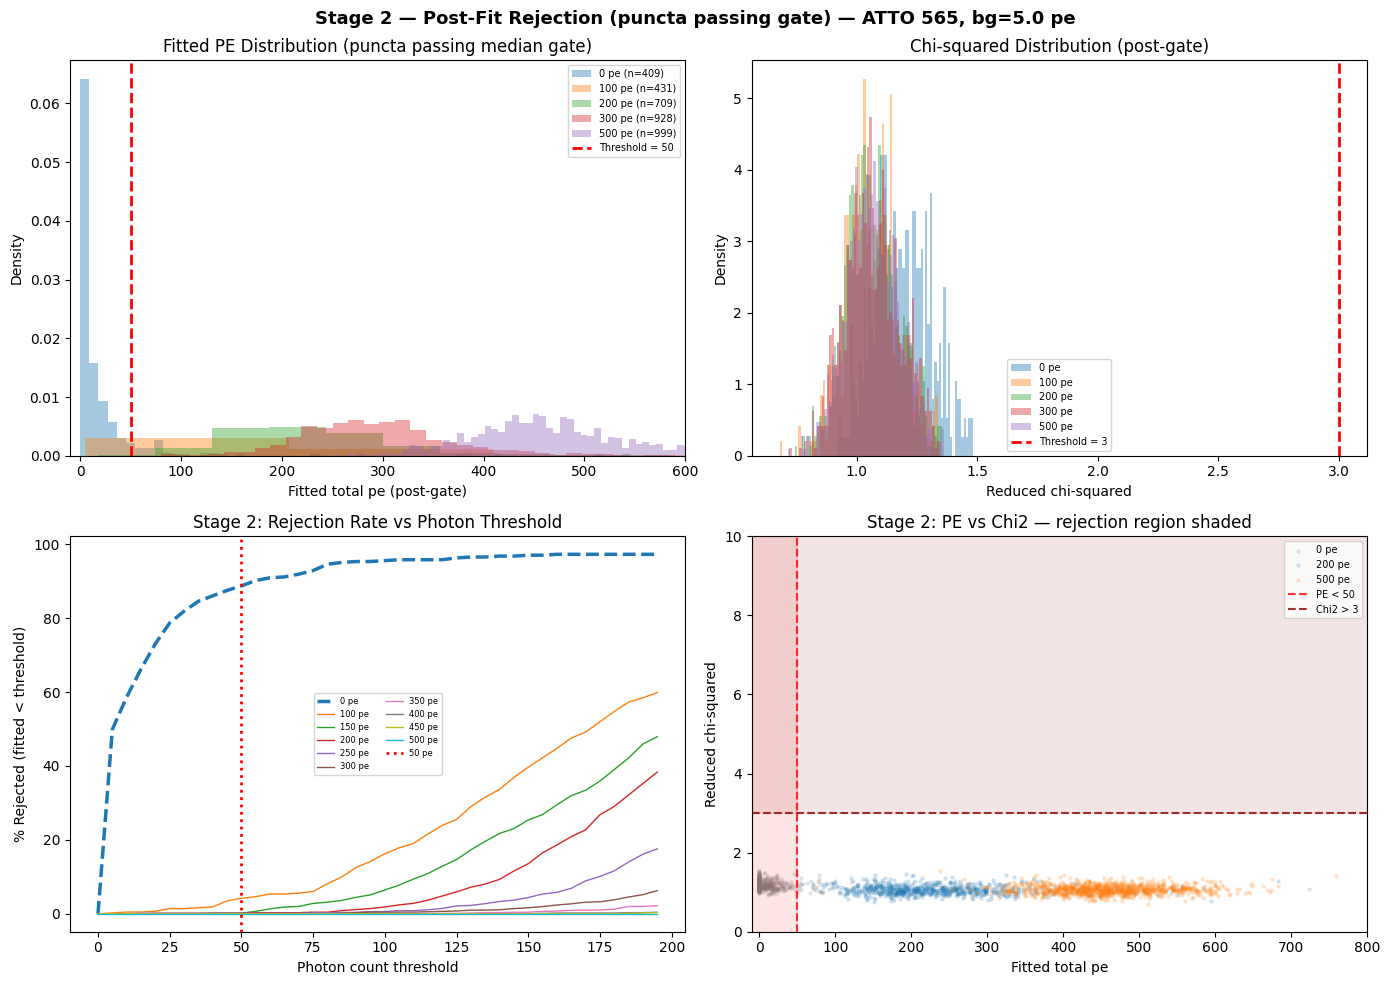

In [7]:
# Stage 2: Post-fit rejection analysis on puncta that passed the gate
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Fitted photon distribution for noise vs signal (gated puncta only)
ax = axes[0, 0]
for p in [0, 100, 200, 300, 500]:
    data = fit_results[p][:, 0]
    valid = data[~np.isnan(data)]
    if len(valid) == 0:
        continue
    clip = np.percentile(valid, 99)
    ax.hist(valid[valid < clip], bins=60, alpha=0.4, density=True, label=f"{p} pe (n={len(valid)})")
ax.axvline(50, color="red", linestyle="--", linewidth=2, label="Threshold = 50")
ax.set_xlabel("Fitted total pe (post-gate)")
ax.set_ylabel("Density")
ax.set_title("Fitted PE Distribution (puncta passing median gate)")
ax.legend(fontsize=7)
ax.set_xlim([-10, 600])

# Panel 2: Chi-squared distribution
ax = axes[0, 1]
for p in [0, 100, 200, 300, 500]:
    data = fit_results[p][:, 4]
    valid = data[~np.isnan(data)]
    if len(valid) == 0:
        continue
    clip = np.percentile(valid, 99)
    ax.hist(valid[valid < clip], bins=60, alpha=0.4, density=True, label=f"{p} pe")
ax.axvline(3, color="red", linestyle="--", linewidth=2, label="Threshold = 3")
ax.set_xlabel("Reduced chi-squared")
ax.set_ylabel("Density")
ax.set_title("Chi-squared Distribution (post-gate)")
ax.legend(fontsize=7)

# Panel 3: Photon threshold sweep on fitted puncta
ax = axes[1, 0]
photon_thresholds = np.arange(0, 200, 5)
for p in photon_levels:
    fitted = fit_results[p][:, 0]
    n_fitted = np.sum(~np.isnan(fitted))
    if n_fitted == 0:
        continue
    rates = [np.nansum(fitted < t) / n_fitted * 100 for t in photon_thresholds]
    ls = "--" if p == 0 else "-"
    lw = 2.5 if p == 0 else 1
    ax.plot(photon_thresholds, rates, ls, linewidth=lw, label=f"{p} pe")
ax.axvline(50, color="red", linestyle=":", linewidth=2, label="50 pe")
ax.set_xlabel("Photon count threshold")
ax.set_ylabel("% Rejected (fitted < threshold)")
ax.set_title("Stage 2: Rejection Rate vs Photon Threshold")
ax.legend(fontsize=6, ncol=2)

# Panel 4: 2D scatter — photons vs chi2 for noise and signal
ax = axes[1, 1]
for p, color in [(0, "grey"), (200, "C0"), (500, "C1")]:
    data = fit_results[p]
    valid = ~np.isnan(data[:, 0])
    if np.sum(valid) == 0:
        continue
    photons = data[valid, 0]
    chi2 = data[valid, 4]
    mask = (photons < 800) & (chi2 < 10)
    ax.scatter(photons[mask], chi2[mask], alpha=0.15, s=5, c=color, label=f"{p} pe")
ax.axvline(50, color="red", linestyle="--", alpha=0.8, label="PE < 50")
ax.axhline(3, color="darkred", linestyle="--", alpha=0.8, label="Chi2 > 3")
ax.axvspan(-10, 50, alpha=0.1, color="red")
ax.axhspan(3, 10, alpha=0.1, color="darkred")
ax.set_xlabel("Fitted total pe")
ax.set_ylabel("Reduced chi-squared")
ax.set_title("Stage 2: PE vs Chi2 — rejection region shaded")
ax.legend(fontsize=7)
ax.set_xlim([-10, 800])
ax.set_ylim([0, 10])

plt.suptitle(
    f"Stage 2 — Post-Fit Rejection (puncta passing gate) — {dye}, bg={background_photons} pe",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 5. Combined Two-Stage Performance

Apply both stages together:
- **Stage 1:** Reject if `A_median < 2 pe` (no fit needed)
- **Stage 2:** Of those fitted, reject if `fitted_pe < photon_cut` OR `chi_squared > 3`

In [8]:
# Sweep photon_cut thresholds with fixed chi2_cut = 3
chi2_cut = 3.0
photon_cuts_to_test = [10, 20, 30, 50, 75, 100]

print(f"Two-stage rejection: Stage 1 gate={median_gate} pe, Stage 2 chi2>{chi2_cut}")
print(f"Sweeping photon_cut thresholds: {photon_cuts_to_test}\n")

for photon_cut in photon_cuts_to_test:
    print(f"--- photon_cut = {photon_cut} pe ---")
    print(
        f"  {'True pe':>8s} | {'N total':>7s} | {'S1 gate':>7s} | {'S2 rej':>7s} | "
        f"{'Final':>7s} | {'% Surv':>7s} | {'Med fit':>8s} | {'Std fit':>9s}"
    )
    print(f"  {'-'*80}")

    for p in photon_levels:
        data = fit_results[p]
        a_med = a_median_values[p]

        n_total = n_bootstrap
        n_s1_rejected = np.sum(a_med < median_gate)  # gated out
        n_fitted = n_total - n_s1_rejected

        # Stage 2: of those fitted, reject on photon count or chi2
        fitted_mask = ~np.isnan(data[:, 0])
        s2_reject = fitted_mask & ((data[:, 0] < photon_cut) | (data[:, 4] > chi2_cut))
        n_s2_rejected = np.sum(s2_reject)

        # Survivors: fitted AND pass both cuts
        survivors = fitted_mask & (data[:, 0] >= photon_cut) & (data[:, 4] <= chi2_cut)
        n_survivors = np.sum(survivors)
        pct_surv = n_survivors / n_total * 100

        if n_survivors > 0:
            surv_data = data[survivors, 0]
            print(
                f"  {p:8d} | {n_total:7d} | {n_s1_rejected:7d} | {n_s2_rejected:7d} | "
                f"{n_survivors:7d} | {pct_surv:6.1f}% | {np.median(surv_data):8.1f} | "
                f"{np.std(surv_data):9.1f}"
            )
        else:
            print(
                f"  {p:8d} | {n_total:7d} | {n_s1_rejected:7d} | {n_s2_rejected:7d} | "
                f"{n_survivors:7d} | {pct_surv:6.1f}% | {'N/A':>8s} | {'N/A':>9s}"
            )
    print()

Two-stage rejection: Stage 1 gate=2.0 pe, Stage 2 chi2>3.0
Sweeping photon_cut thresholds: [10, 20, 30, 50, 75, 100]

--- photon_cut = 10 pe ---
   True pe | N total | S1 gate |  S2 rej |   Final |  % Surv |  Med fit |   Std fit
  --------------------------------------------------------------------------------
         0 |    1000 |     585 |     240 |     169 |   16.9% |     25.2 |    1097.9
       100 |    1000 |     563 |       2 |     429 |   42.9% |    172.1 |   17458.5
       150 |    1000 |     391 |       0 |     607 |   60.7% |    196.9 |   10055.9
       200 |    1000 |     286 |       0 |     709 |   70.9% |    218.3 |     691.0
       250 |    1000 |     157 |       0 |     843 |   84.3% |    255.2 |    2391.6
       300 |    1000 |      71 |       0 |     928 |   92.8% |    289.4 |     279.2
       350 |    1000 |      34 |       0 |     966 |   96.6% |    330.5 |     134.8
       400 |    1000 |       9 |       0 |     991 |   99.1% |    373.7 |      85.1
       450 |    

## 6. Visualise: Where Each Stage Catches Noise

Breakdown of what gets caught by Stage 1 (median gate) vs Stage 2 (fit quality).

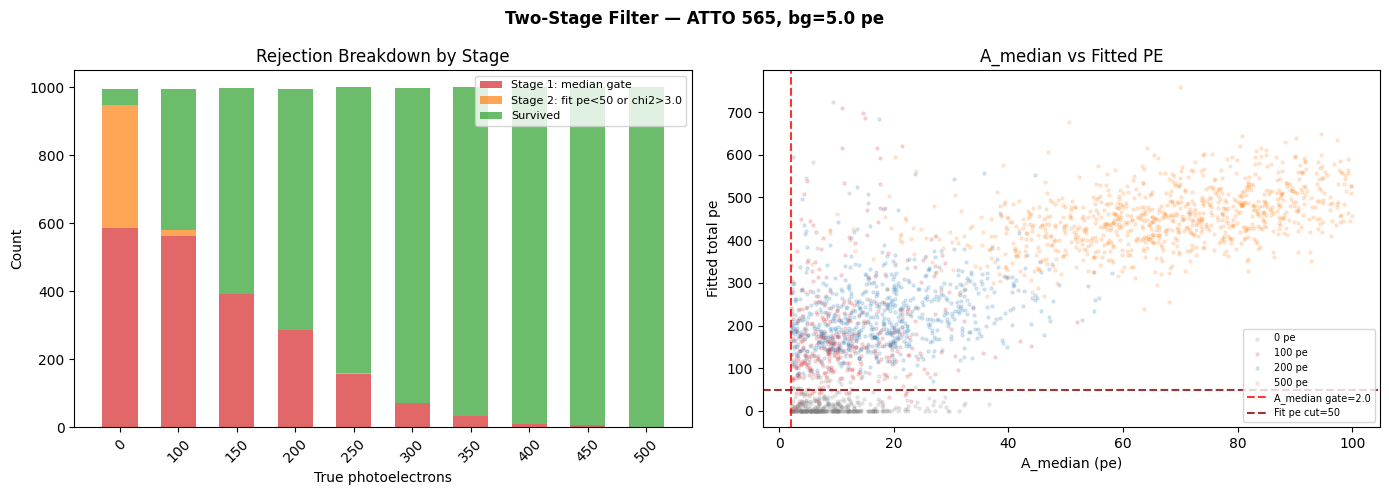

In [9]:
# Pick a representative photon_cut for the visualisation
photon_cut = 50
chi2_cut = 3.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Stacked bar — breakdown per photon level
ax = axes[0]
x_pos = np.arange(len(photon_levels))
bar_width = 0.6

s1_counts = []  # gated by median
s2_counts = []  # passed gate, rejected by fit
surv_counts = []  # survived both

for p in photon_levels:
    a_med = a_median_values[p]
    data = fit_results[p]

    n_s1 = np.sum(a_med < median_gate)
    fitted_mask = ~np.isnan(data[:, 0])
    s2_mask = fitted_mask & ((data[:, 0] < photon_cut) | (data[:, 4] > chi2_cut))
    n_s2 = np.sum(s2_mask)
    n_surv = np.sum(fitted_mask & (data[:, 0] >= photon_cut) & (data[:, 4] <= chi2_cut))

    s1_counts.append(n_s1)
    s2_counts.append(n_s2)
    surv_counts.append(n_surv)

s1_counts = np.array(s1_counts)
s2_counts = np.array(s2_counts)
surv_counts = np.array(surv_counts)

ax.bar(x_pos, s1_counts, bar_width, label="Stage 1: median gate", color="C3", alpha=0.7)
ax.bar(
    x_pos, s2_counts, bar_width, bottom=s1_counts,
    label=f"Stage 2: fit pe<{photon_cut} or chi2>{chi2_cut}", color="C1", alpha=0.7,
)
ax.bar(
    x_pos, surv_counts, bar_width, bottom=s1_counts + s2_counts,
    label="Survived", color="C2", alpha=0.7,
)
ax.set_xticks(x_pos)
ax.set_xticklabels([str(p) for p in photon_levels], rotation=45)
ax.set_xlabel("True photoelectrons")
ax.set_ylabel("Count")
ax.set_title("Rejection Breakdown by Stage")
ax.legend(fontsize=8)

# Panel 2: A_median vs fitted photons scatter (for puncta that were fitted)
ax = axes[1]
for p, color in [(0, "grey"), (100, "C3"), (200, "C0"), (500, "C1")]:
    data = fit_results[p]
    a_med = a_median_values[p]
    fitted = ~np.isnan(data[:, 0])
    if np.sum(fitted) == 0:
        continue
    x_vals = a_med[fitted]
    y_vals = data[fitted, 0]
    mask = (y_vals < 800) & (x_vals < 100)
    ax.scatter(x_vals[mask], y_vals[mask], alpha=0.15, s=5, c=color, label=f"{p} pe")

ax.axvline(median_gate, color="red", linestyle="--", alpha=0.8, label=f"A_median gate={median_gate}")
ax.axhline(photon_cut, color="darkred", linestyle="--", alpha=0.8, label=f"Fit pe cut={photon_cut}")
ax.set_xlabel("A_median (pe)")
ax.set_ylabel("Fitted total pe")
ax.set_title("A_median vs Fitted PE")
ax.legend(fontsize=7)

plt.suptitle(
    f"Two-Stage Filter — {dye}, bg={background_photons} pe",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 7. Box Plots: Before vs After Two-Stage Rejection

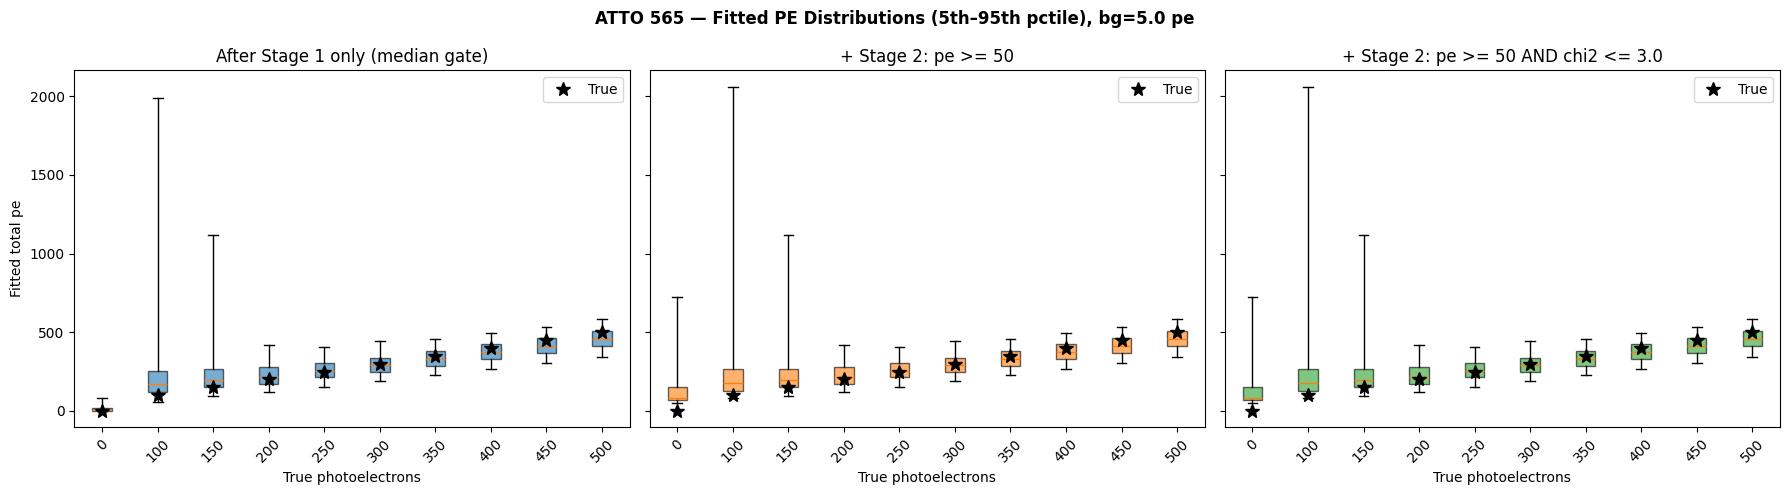

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
positions = np.arange(len(photon_levels))
width = 0.35

# Panel 1: All fits (no rejection)
all_data = []
for p in photon_levels:
    d = fit_results[p][:, 0]
    all_data.append(d[~np.isnan(d)])

bp1 = axes[0].boxplot(
    all_data, positions=positions, widths=width, patch_artist=True,
    showfliers=False, whis=[5, 95],
)
for patch in bp1["boxes"]:
    patch.set_facecolor("C0")
    patch.set_alpha(0.6)
axes[0].plot(positions, photon_levels, "k*", markersize=10, label="True", zorder=5)
axes[0].set_xticks(positions)
axes[0].set_xticklabels([str(p) for p in photon_levels], rotation=45)
axes[0].set_xlabel("True photoelectrons")
axes[0].set_ylabel("Fitted total pe")
axes[0].set_title("After Stage 1 only (median gate)")
axes[0].legend()

# Panel 2: After Stage 2 (photon cut only, no chi2)
filt_phot = []
for p in photon_levels:
    data = fit_results[p]
    fitted = ~np.isnan(data[:, 0])
    mask = fitted & (data[:, 0] >= photon_cut)
    filt_phot.append(data[mask, 0])

bp2 = axes[1].boxplot(
    filt_phot, positions=positions, widths=width, patch_artist=True,
    showfliers=False, whis=[5, 95],
)
for patch in bp2["boxes"]:
    patch.set_facecolor("C1")
    patch.set_alpha(0.6)
axes[1].plot(positions, photon_levels, "k*", markersize=10, label="True", zorder=5)
axes[1].set_xticks(positions)
axes[1].set_xticklabels([str(p) for p in photon_levels], rotation=45)
axes[1].set_xlabel("True photoelectrons")
axes[1].set_title(f"+ Stage 2: pe >= {photon_cut}")
axes[1].legend()

# Panel 3: After both Stage 2 cuts (photon + chi2)
filt_both = []
for p in photon_levels:
    data = fit_results[p]
    fitted = ~np.isnan(data[:, 0])
    mask = fitted & (data[:, 0] >= photon_cut) & (data[:, 4] <= chi2_cut)
    filt_both.append(data[mask, 0])

bp3 = axes[2].boxplot(
    filt_both, positions=positions, widths=width, patch_artist=True,
    showfliers=False, whis=[5, 95],
)
for patch in bp3["boxes"]:
    patch.set_facecolor("C2")
    patch.set_alpha(0.6)
axes[2].plot(positions, photon_levels, "k*", markersize=10, label="True", zorder=5)
axes[2].set_xticks(positions)
axes[2].set_xticklabels([str(p) for p in photon_levels], rotation=45)
axes[2].set_xlabel("True photoelectrons")
axes[2].set_title(f"+ Stage 2: pe >= {photon_cut} AND chi2 <= {chi2_cut}")
axes[2].legend()

plt.suptitle(
    f"{dye} — Fitted PE Distributions (5th–95th pctile), bg={background_photons} pe",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 8. Summary

In [11]:
print("=" * 75)
print(f"SUMMARY: Two-Stage Rejection — {dye}, bg={background_photons} pe")
print(f"  Stage 1: Median gate — reject if A_median < {median_gate} pe")
print(f"  Stage 2: Post-fit — reject if fitted_pe < {photon_cut} OR chi2 > {chi2_cut}")
print("=" * 75)

print(f"\n{'True pe':>8s} | {'S1 gate':>7s} | {'S2 rej':>7s} | {'Total rej':>9s} | "
      f"{'Survive':>7s} | {'% Surv':>7s} | {'Med fit':>8s} | {'Bias':>8s}")
print("-" * 85)

for p in photon_levels:
    data = fit_results[p]
    a_med = a_median_values[p]

    n_s1 = np.sum(a_med < median_gate)
    fitted = ~np.isnan(data[:, 0])
    s2_rej = fitted & ((data[:, 0] < photon_cut) | (data[:, 4] > chi2_cut))
    n_s2 = np.sum(s2_rej)
    survivors = fitted & (data[:, 0] >= photon_cut) & (data[:, 4] <= chi2_cut)
    n_surv = np.sum(survivors)
    total_rej = n_s1 + n_s2
    pct = n_surv / n_bootstrap * 100

    if n_surv > 0:
        med = np.median(data[survivors, 0])
        bias = med - p
        print(f"{p:8d} | {n_s1:7d} | {n_s2:7d} | {total_rej:9d} | "
              f"{n_surv:7d} | {pct:6.1f}% | {med:8.1f} | {bias:+8.1f}")
    else:
        print(f"{p:8d} | {n_s1:7d} | {n_s2:7d} | {total_rej:9d} | "
              f"{n_surv:7d} | {pct:6.1f}% | {'N/A':>8s} | {'N/A':>8s}")

# Key performance metrics
noise_s1 = np.sum(a_median_values[0] < median_gate)
noise_fitted = np.sum(~np.isnan(fit_results[0][:, 0]))
noise_surv = np.sum(
    ~np.isnan(fit_results[0][:, 0])
    & (fit_results[0][:, 0] >= photon_cut)
    & (fit_results[0][:, 4] <= chi2_cut)
)
noise_total_rej = n_bootstrap - noise_surv

print(f"\nKEY METRICS:")
print(f"  Noise (0 pe): {noise_total_rej}/{n_bootstrap} rejected "
      f"({noise_total_rej/n_bootstrap*100:.1f}%), "
      f"{noise_surv} false positives ({noise_surv/n_bootstrap*100:.1f}%)")
print(f"    Stage 1 caught: {noise_s1} ({noise_s1/n_bootstrap*100:.1f}%)")
print(f"    Stage 2 caught: {noise_total_rej - noise_s1} "
      f"({(noise_total_rej - noise_s1)/n_bootstrap*100:.1f}%)")

# False negatives at low photon counts
for p_test in [100, 150, 200]:
    if p_test in photon_levels:
        surv = np.sum(
            ~np.isnan(fit_results[p_test][:, 0])
            & (fit_results[p_test][:, 0] >= photon_cut)
            & (fit_results[p_test][:, 4] <= chi2_cut)
        )
        lost = n_bootstrap - surv
        print(f"  Signal ({p_test} pe): {lost}/{n_bootstrap} lost "
              f"({lost/n_bootstrap*100:.1f}% false negative)")

print(f"\n  NOTE: Fitter returns PHOTOELECTRONS (data is ADU→pe before fitting).")

SUMMARY: Two-Stage Rejection — ATTO 565, bg=5.0 pe
  Stage 1: Median gate — reject if A_median < 2.0 pe
  Stage 2: Post-fit — reject if fitted_pe < 50 OR chi2 > 3.0

 True pe | S1 gate |  S2 rej | Total rej | Survive |  % Surv |  Med fit |     Bias
-------------------------------------------------------------------------------------
       0 |     585 |     363 |       948 |      46 |    4.6% |     79.5 |    +79.5
     100 |     563 |      18 |       581 |     413 |   41.3% |    175.1 |    +75.1
     150 |     391 |       1 |       392 |     606 |   60.6% |    197.0 |    +47.0
     200 |     286 |       1 |       287 |     708 |   70.8% |    218.9 |    +18.9
     250 |     157 |       1 |       158 |     842 |   84.2% |    255.4 |     +5.4
     300 |      71 |       0 |        71 |     928 |   92.8% |    289.4 |    -10.6
     350 |      34 |       0 |        34 |     966 |   96.6% |    330.5 |    -19.5
     400 |       9 |       0 |         9 |     991 |   99.1% |    373.7 |    -26.3
 